# Part D – Cross-Validation Strategies

In [6]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

import matplotlib.pyplot as plt

In [7]:
base_model = Ridge(alpha=1.0)

In [8]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    base_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='r2'
)

print("K-Fold Scores:")
print(kfold_scores)

print("Average Score:")
print(kfold_scores.mean())

K-Fold Scores:
[0.91935079 0.90754113 0.91432713 0.92046562 0.9198908 ]
Average Score:
0.9163150939132224


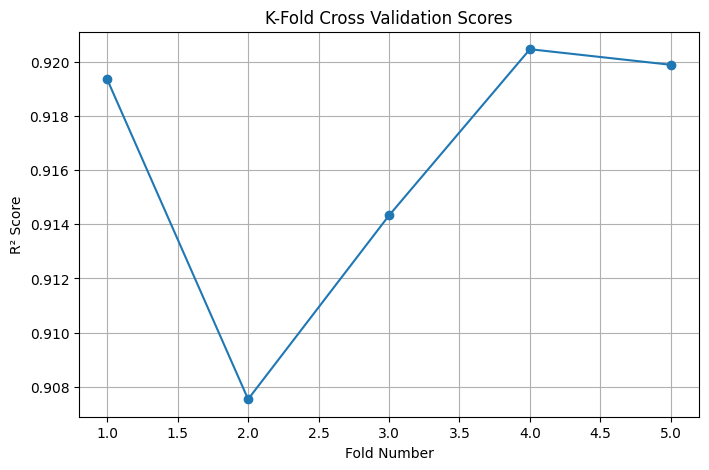

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    kfold_scores,
    marker='o'
)

plt.title("K-Fold Cross Validation Scores")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")

plt.grid(True)

plt.show()

In [10]:
y_binned = pd.qcut(
    y_train,
    q=5,
    labels=False
)

In [11]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_idx, test_idx in skf.split(
    X_train_scaled,
    y_binned
):

    X_train_fold = X_train_scaled[train_idx]
    X_test_fold = X_train_scaled[test_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_test_fold = y_train.iloc[test_idx]

    base_model.fit(
        X_train_fold,
        y_train_fold
    )

    score = base_model.score(
        X_test_fold,
        y_test_fold
    )

    stratified_scores.append(score)

print(stratified_scores)
print(np.mean(stratified_scores))

[0.9117293979434353, 0.9231087755481787, 0.917847230574924, 0.9187967463923205, 0.9125609750918875]
0.9168086251101493


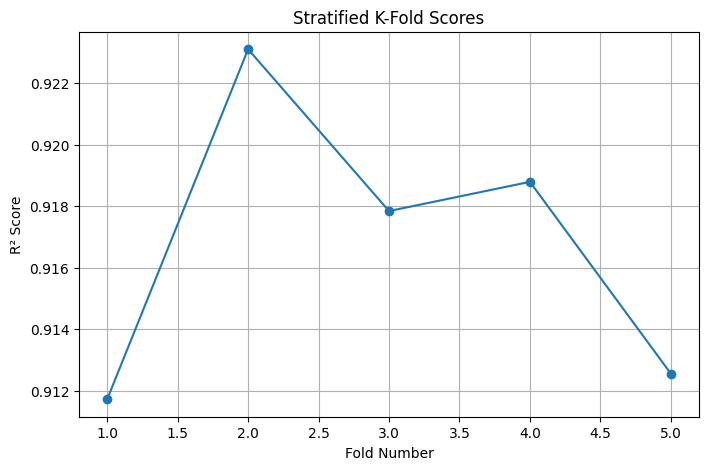

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    stratified_scores,
    marker='o'
)

plt.title("Stratified K-Fold Scores")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")

plt.grid(True)

plt.show()

In [13]:
loo = LeaveOneOut()

loo_scores = cross_val_score(
    base_model,
    X_train_scaled,
    y_train,
    cv=loo,
    scoring='neg_mean_squared_error'
)

print("Number of Iterations:")
print(len(loo_scores))

print("Average MSE:")
print(np.mean(loo_scores))

Number of Iterations:
3040
Average MSE:
-6211505500301.769


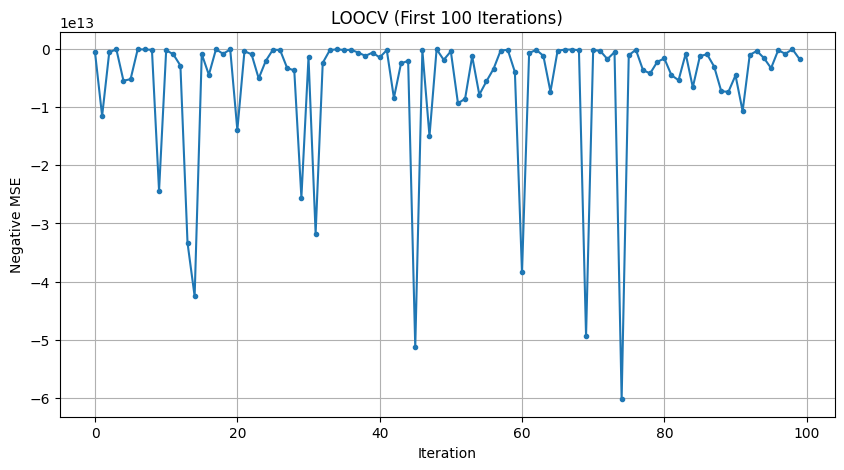

In [14]:
plt.figure(figsize=(10,5))

plt.plot(
    loo_scores[:100],
    marker='.'
)

plt.title("LOOCV (First 100 Iterations)")
plt.xlabel("Iteration")
plt.ylabel("Negative MSE")

plt.grid(True)

plt.show()

In [16]:
tscv = TimeSeriesSplit(
    n_splits=5
)

time_scores = cross_val_score(
    base_model,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring='r2'
)

print(time_scores)
print(time_scores.mean())

[0.90791361 0.91449322 0.92346236 0.91795908 0.9165715 ]
0.9160799565376523


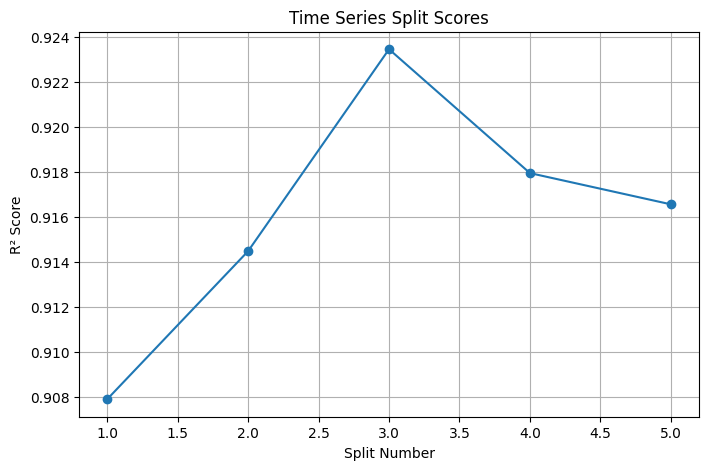

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    time_scores,
    marker='o'
)

plt.title("Time Series Split Scores")
plt.xlabel("Split Number")
plt.ylabel("R² Score")

plt.grid(True)

plt.show()

In [18]:
cv_results = pd.DataFrame({

    "Method":[
        "K-Fold",
        "Stratified K-Fold",
        "Time Series Split"
    ],

    "Average Score":[
        np.mean(kfold_scores),
        np.mean(stratified_scores),
        np.mean(time_scores)
    ]
})

print(cv_results)

              Method  Average Score
0             K-Fold       0.916315
1  Stratified K-Fold       0.916809
2  Time Series Split       0.916080


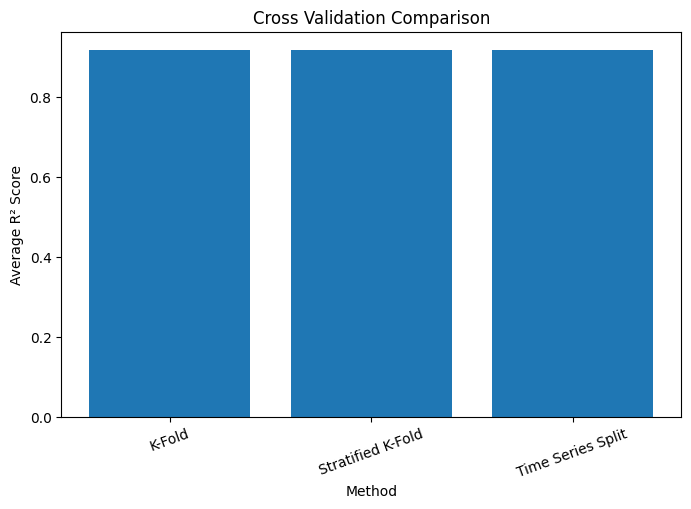

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Method"],
    cv_results["Average Score"]
)

plt.title("Cross Validation Comparison")
plt.xlabel("Method")
plt.ylabel("Average R² Score")

plt.xticks(rotation=20)

plt.show()

#  Interpretation

### K-Fold

* Reliable and balanced
* Most commonly used

### Stratified K-Fold

* Preserves target distribution
* More stable when target varies significantly

### LOOCV

* Uses maximum training data
* Computationally expensive

### Time Series Split

* Prevents future data leakage
* Best for time-based datasets

------

# Conclusion for Part D

The Ridge Regression model was evaluated using:

1. K-Fold Cross Validation
2. Stratified K-Fold Cross Validation
3. Leave-One-Out Cross Validation
4. Time Series Split

K-Fold and Stratified K-Fold generally provide the most reliable evaluation for this House Price Prediction dataset. Time Series Split is useful when preserving chronological order is important, while LOOCV is computationally expensive but uses maximum training data.
